In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
from fewjaxstudy.waveform import build_waveform

In [3]:
from fewjaxstudy.amplitude.ampinterp import get_amplitude_interpolant

In [4]:
ampint = get_amplitude_interpolant("../amps-prep/amp_interp_grid.npy")

In [5]:
t_eval = jnp.array([3e7,])
m1 = 1e5
m2 = 1e1
a = 0.1
p0 = 10.0
e0 = 0.6
theta = jnp.pi / 3

T = 1

n_modes = jnp.arange(-55, 56)
l_modes = jnp.ones_like(n_modes) * 2
m_modes = jnp.ones_like(n_modes) * 2


In [6]:
t_out, length, coeffs_amp, coeffs_phase = build_waveform(ampint, t_eval, m1, m2, a, p0, e0, theta, T, l_modes, m_modes, n_modes)

In [7]:
from fewjaxstudy.summation.interpolatedsum import interpolated_summation_chunked

In [8]:
# def interpolated_summation_chunked(t_eval, t_knots, amplitude_coefficients, phase_coefficients, batch_size):

t_eval = jnp.arange(1e6) * 1.0

outp = interpolated_summation_chunked(
    t_eval, t_out, coeffs_amp.transpose(1,2,0), coeffs_phase.transpose(1,2,0), batch_size=1000
).block_until_ready()

In [ ]:
%timeit interpolated_summation_chunked(t_eval, t_out, coeffs_amp.transpose(1,2,0), coeffs_phase.transpose(1,2,0), batch_size=1000)

(0.0, 10000.0)

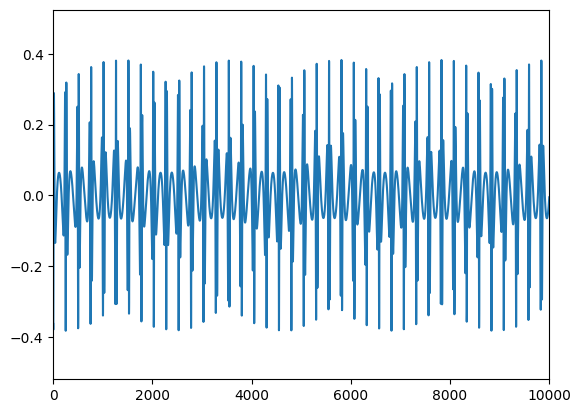

In [9]:
plt.plot(t_eval, outp.real)
plt.xlim(0, 10000)

In [10]:
# lotsa_waves = jax.vmap(build_waveform, in_axes = (None, None, None, None, 0, None, None, None, None, None, None))

# pvals = jnp.linspace(10., 12., 10)

# outs = lotsa_waves(t_eval, m1, m2, a, pvals, e0, theta, T, l_modes, m_modes, n_modes)

In [9]:
# %timeit build_waveform(t_eval, m1, m2, a, p0, e0, theta, T, l_modes, m_modes, n_modes)

In [10]:
# plt.plot(t_out, coeffs_phase[0,:,0])